In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

In [9]:
df = pd.read_csv("Dataset_new.csv")

In [10]:
years = sorted(df['year'].unique())

results_list = []

feature_cols = [
        'year',
        'Rndrng_NPI',
        'Rndrng_Prvdr_Type',
        'Rndrng_Prvdr_State_Abrvtn',
        'Rndrng_Prvdr_Mdcr_Prtcptg_Ind',
        'log_Tot_Benes',
        'log_Tot_Srvcs',
        'Bene_Avg_Age',
        'Bene_Avg_Risk_Scre',
]
target_col = 'Tot_Mdcr_Pymt_Amt_log'

In [17]:
yearly_summary_list = []
for y in years[1:]:
    train_year = y - 1
    test_year = y

    train_df = df[df['year'] == train_year].copy()
    test_df = df[df['year'] == test_year].copy()
    
    # keep only providers present in both years
    common_npi = set(train_df['Rndrng_NPI']).intersection(set(test_df['Rndrng_NPI']))

    train_df = train_df[train_df['Rndrng_NPI'].isin(common_npi)]
    test_df = test_df[test_df['Rndrng_NPI'].isin(common_npi)]

    X_train = train_df[feature_cols]
    y_train = train_df[target_col]

    X_test = test_df[feature_cols]
    y_test = test_df[target_col]
    
    # one-hot encode
    X_train = pd.get_dummies(X_train, drop_first=True)
    X_test = pd.get_dummies(X_test, drop_first=True)

    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)
    
    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    yearly_summary_list = []

    temp = test_df[['Rndrng_NPI', 'year']].copy()
    temp['actual'] = y_test.values
    temp['predicted'] = y_pred

    temp['actual_dollars'] = np.expm1(temp['actual'])
    temp['predicted_dollars'] = np.expm1(temp['predicted'])

    yearly_summary_list.append({
    'year': test_year,
    'sum_actual': temp['actual'].sum(),
    'sum_predicted': temp['predicted'].sum(),
    'sum_ratio_log': temp['predicted'].sum() / temp['actual'].sum(),
    'sum_ratio_dollars': temp['predicted_dollars'].sum() / temp['actual_dollars'].sum()
     })

    yearly_compare = pd.DataFrame(yearly_summary_list)
    print(yearly_compare)

   year    sum_actual  sum_predicted  sum_ratio_log  sum_ratio_dollars
0  2014  9.336428e+06   9.312561e+06       0.997444           0.979421
   year    sum_actual  sum_predicted  sum_ratio_log  sum_ratio_dollars
0  2015  9.625866e+06   9.634016e+06       1.000847           1.002112
   year    sum_actual  sum_predicted  sum_ratio_log  sum_ratio_dollars
0  2016  9.928630e+06   9.944801e+06       1.001629           0.970217
   year    sum_actual  sum_predicted  sum_ratio_log  sum_ratio_dollars
0  2017  1.024627e+07   1.025824e+07       1.001167           0.955345
   year    sum_actual  sum_predicted  sum_ratio_log  sum_ratio_dollars
0  2018  1.054869e+07   1.055150e+07       1.000266           0.943088
   year    sum_actual  sum_predicted  sum_ratio_log  sum_ratio_dollars
0  2019  1.085899e+07   1.085464e+07       0.999599           0.932753
   year    sum_actual  sum_predicted  sum_ratio_log  sum_ratio_dollars
0  2020  1.085785e+07   1.086488e+07       1.000648            0.91769
   yea

   year        actual     predicted  sum_ratio_log  sum_ratio_dollars
0  2014  8.921250e+10  8.737657e+10       0.997444           0.979421
1  2015  9.190412e+10  9.209821e+10       1.000847           1.002112
2  2016  9.403771e+10  9.123695e+10       1.001629           0.970217
3  2017  9.613457e+10  9.184169e+10       1.001167           0.955345
4  2018  9.941062e+10  9.375295e+10       1.000266           0.943088
5  2019  1.037700e+11  9.679172e+10       0.999599           0.932753
6  2020  9.530160e+10  8.745733e+10       1.000648           0.917690
7  2021  1.066070e+11  9.543825e+10       0.993128           0.895235
8  2022  1.040903e+11  9.840942e+10       1.002735           0.945424
9  2023  1.094780e+11  9.841068e+10       1.000008           0.898908


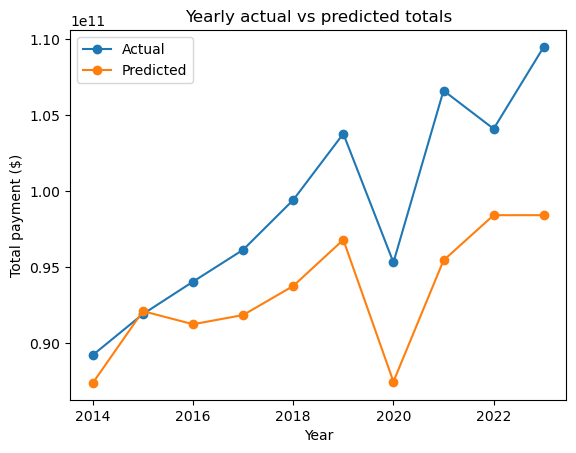

In [25]:
yearly_summary_list = []

for y in years[1:]:
    train_year = y - 1
    test_year = y

    train_df = df[df['year'] == train_year].copy()
    test_df = df[df['year'] == test_year].copy()

    common_npi = set(train_df['Rndrng_NPI']).intersection(set(test_df['Rndrng_NPI']))
    train_df = train_df[train_df['Rndrng_NPI'].isin(common_npi)]
    test_df = test_df[test_df['Rndrng_NPI'].isin(common_npi)]

    X_train = train_df[feature_cols]
    y_train = train_df[target_col]

    X_test = test_df[feature_cols]
    y_test = test_df[target_col]

    X_train = pd.get_dummies(X_train, drop_first=True)
    X_test = pd.get_dummies(X_test, drop_first=True)
    X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    temp = test_df[['Rndrng_NPI', 'year']].copy()
    temp['actual'] = y_test.values
    temp['predicted'] = y_pred

    temp['actual_dollars'] = np.expm1(temp['actual'])
    temp['predicted_dollars'] = np.expm1(temp['predicted'])

    results_list.append(temp)

    yearly_summary_list.append({
        'year': test_year,
        'actual': temp['actual_dollars'].sum(),
        'predicted': temp['predicted_dollars'].sum(),
        'sum_ratio_log': temp['predicted'].sum() / temp['actual'].sum(),
        'sum_ratio_dollars': temp['predicted_dollars'].sum() / temp['actual_dollars'].sum()
    })

results = pd.concat(results_list, ignore_index=True)
yearly_compare = pd.DataFrame(yearly_summary_list)

print(yearly_compare)

plt.plot(yearly_compare['year'], yearly_compare['actual'], marker='o', label='Actual')
plt.plot(yearly_compare['year'], yearly_compare['predicted'], marker='o', label='Predicted')
plt.xlabel('Year')
plt.ylabel('Total payment ($)')
plt.title('Yearly actual vs predicted totals')
plt.legend()
plt.show()

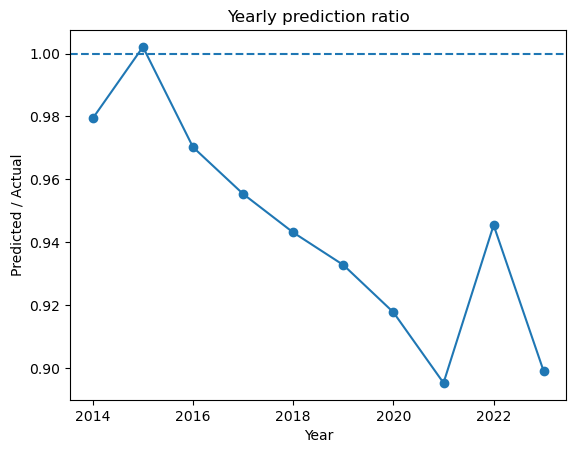

In [21]:
yearly_compare['ratio'] = yearly_compare['predicted'] / yearly_compare['actual']

plt.plot(yearly_compare['year'], yearly_compare['ratio'], marker='o')
plt.axhline(1.0, linestyle='--')
plt.xlabel('Year')
plt.ylabel('Predicted / Actual')
plt.title('Yearly prediction ratio')
plt.show()

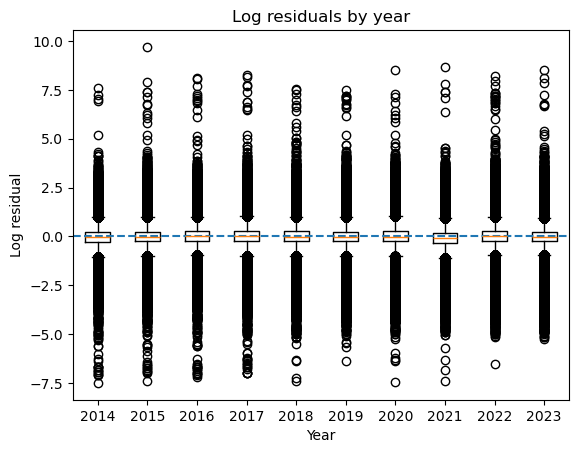

In [26]:
results['log_residual'] = results['predicted'] - results['actual']

plt.boxplot(
    [results.loc[results['year'] == y, 'log_residual'] for y in sorted(results['year'].unique())],
    tick_labels=sorted(results['year'].unique())
)
plt.axhline(0.0, linestyle='--')
plt.xlabel('Year')
plt.ylabel('Log residual')
plt.title('Log residuals by year')
plt.show()
